# Themes and backends

Every view shares one theme system and reads values through a tiny adapter, so the look and the input source are both flexible.

In [1]:
import numpy as np
import rainbow_tensor as rt

## Dark theme

Pass `theme="dark"` to any call for a dark variant.

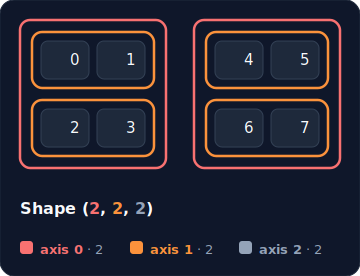

In [2]:
rt.shape(np.arange(8).reshape(2, 2, 2), theme="dark")

## A custom theme

A theme is a plain object. Derive a tweaked copy with `variant`, for roomier cells.

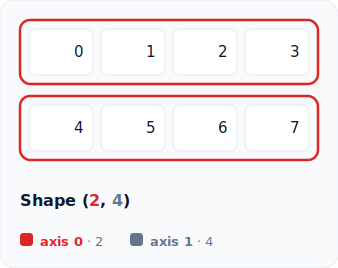

In [3]:
roomy = rt.LIGHT.variant(cell_w=64, cell_h=46)
rt.shape(np.arange(8).reshape(2, 4), theme=roomy)

## A global default

Set a default axis ramp once and every later call picks it up. Passing `None` restores the built in ramp.

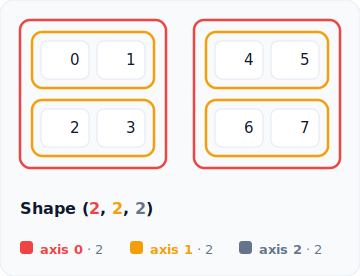

In [4]:
rt.set_default_axis_colors(["#ef4444", "#f59e0b", "#10b981"])
out = rt.shape(np.arange(8).reshape(2, 2, 2))
rt.set_default_axis_colors(None)
out

## Backend arrays

NumPy, PyTorch, and JAX arrays all work through the same duck typed adapter. The optional backends render only when they are installed.

In [5]:
import importlib.util

if importlib.util.find_spec("torch") is not None:
    import torch

    display(rt.shape(torch.arange(6).reshape(2, 3)))
if importlib.util.find_spec("jax") is not None:
    import jax.numpy as jnp

    display(rt.shape(jnp.arange(6).reshape(2, 3)))

## Big tensors

Large shapes draw a compact preview instead of every cell, and a selected position is pinned into the preview.

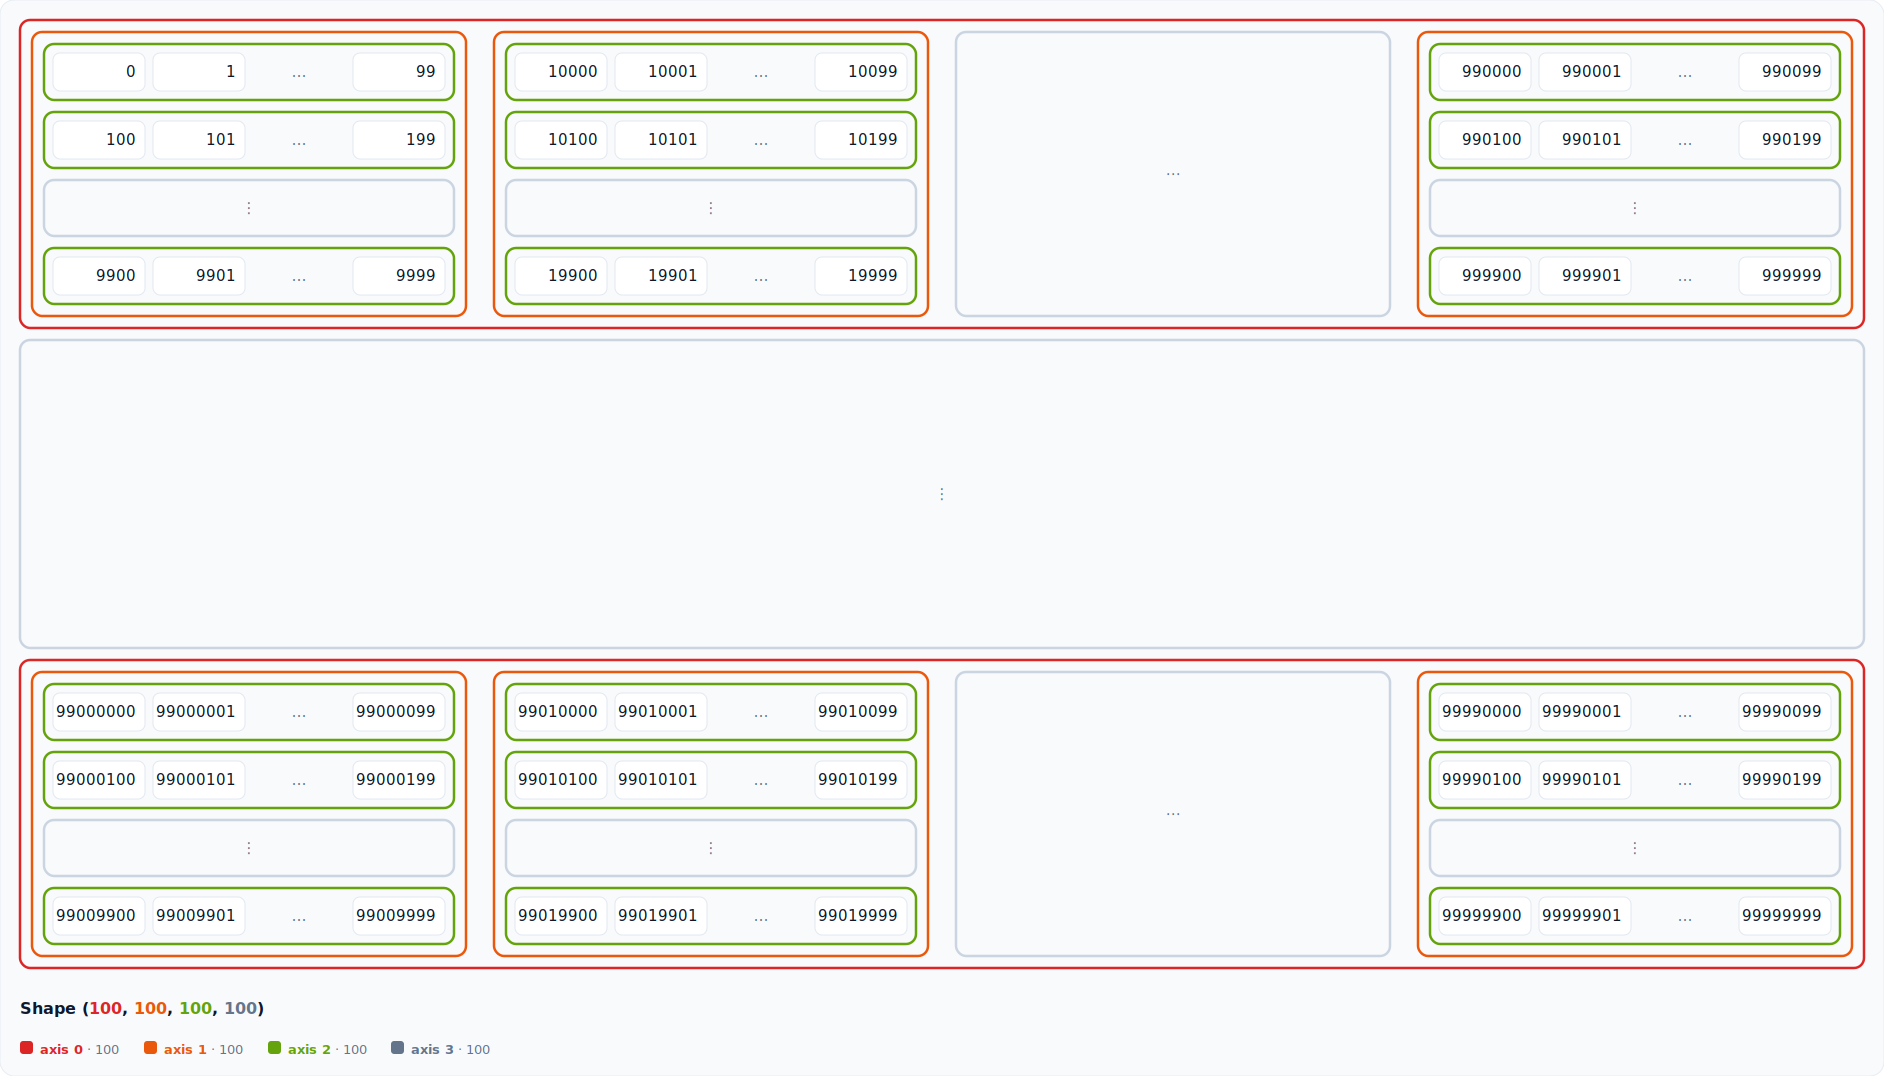

Large preview for tensor (100, 100, 100, 100) draws at most 240 real cells from 100000000 total.
Hidden axes [0, 1, 2, 3] keep the head, selected positions, and tail.


In [6]:
rt.shape((100, 100, 100, 100))

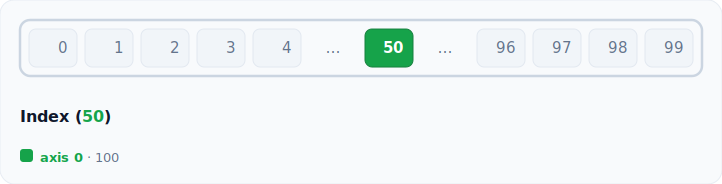

Original shape: (100,)
Index: 50
Result shape: ()
Axis 0 is removed because integer index 50 is used.
Large preview for tensor (100,) draws at most 240 real cells from 100 total.
Hidden axes [0] keep the head, selected positions, and tail.


In [7]:
rt.index((100,), (50,))